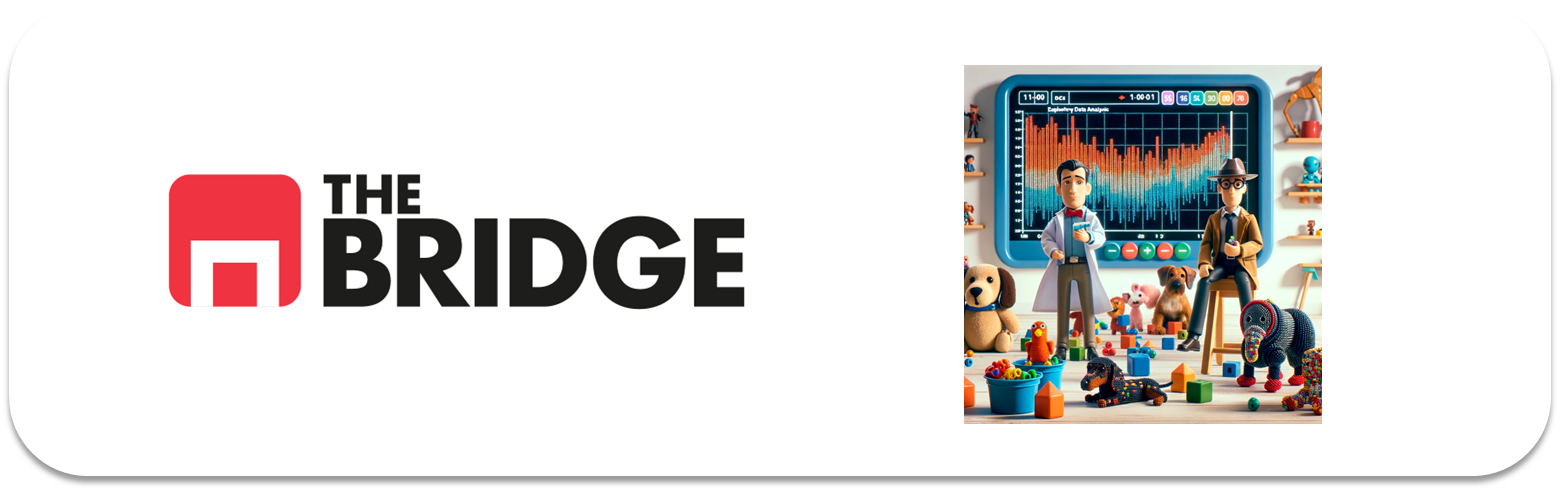

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from bootcampviztools import plot_categorical_numerical_relationship, plot_combined_graphs, \
    pinta_distribucion_categoricas, plot_grouped_boxplots, plot_categorical_relationship_fin, plot_grouped_histograms, \
        grafico_dispersion_con_correlacion, bubble_plot



## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [4]:
df_titanic = pd.read_csv("./data/titanic.csv")
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [5]:
columnas_a_eliminar = ["deck", "survived", "pclass", "embarked"]

#axis=1 porque son columnas e inplace=True aplica el cambio directamente a mi dataframe
df_titanic.drop(columns=columnas_a_eliminar, axis=1, inplace=True)

#Compruebo
print("Columnas restantes:", df_titanic.columns.tolist())

Columnas restantes: ['sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [6]:
# Sumo las columnas de parientes
# El resultado lo guardo en 'family_members'
df_titanic["family_members"] = df_titanic["parch"] + df_titanic["sibsp"]

#Elimino las originales para no duplicar info
df_titanic.drop(columns=["parch", "sibsp"], inplace=True)

df_titanic[["family_members"]].head()

,family_members
0,1
1,1
2,0
3,1
4,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [7]:
moda_embark = df_titanic["embark_town"].mode()[0]

#Relleno los valores nulos con la moda
df_titanic["embark_town"] = df_titanic["embark_town"].fillna(moda_embark)

print("Nulos en embark_town:", df_titanic["embark_town"].isnull().sum())

Nulos en embark_town: 0


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [8]:
#Calculo la media de edad para cada categoría
print("Medias de edad por grupo:")
print(df_titanic.groupby('who')['age'].mean())

#Imputación:relleno los nulos usando la media de su propio grupo
#Transform para que cada nulo reciba la media que le corresponde a su categoría
df_titanic['age'] = df_titanic['age'].fillna(df_titanic.groupby('who')['age'].transform('mean'))

print("\nNulos restantes en age:", df_titanic['age'].isnull().sum())

Medias de edad por grupo:
who
child     6.369518
man      33.173123
woman    32.000000
Name: age, dtype: float64

Nulos restantes en age: 0


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

1. Análisis visual de supervivencia por grupo (man, woman, child)


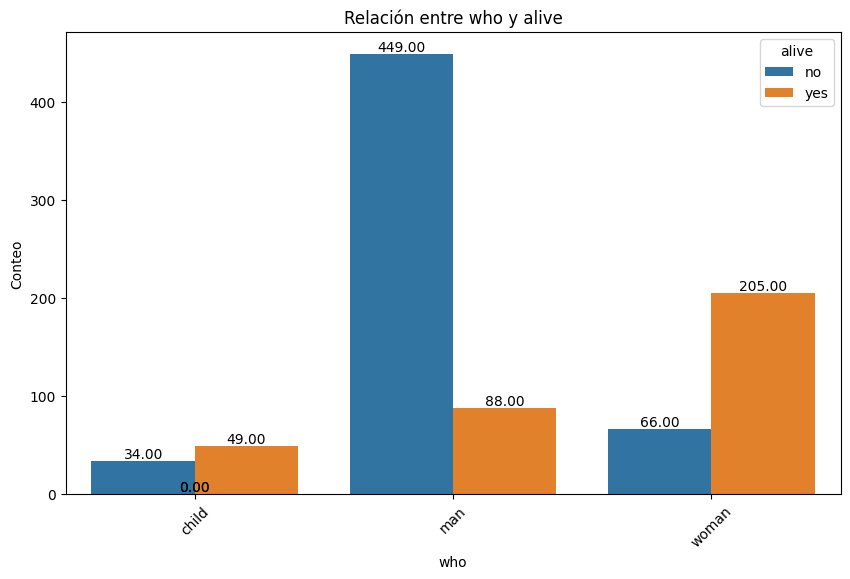

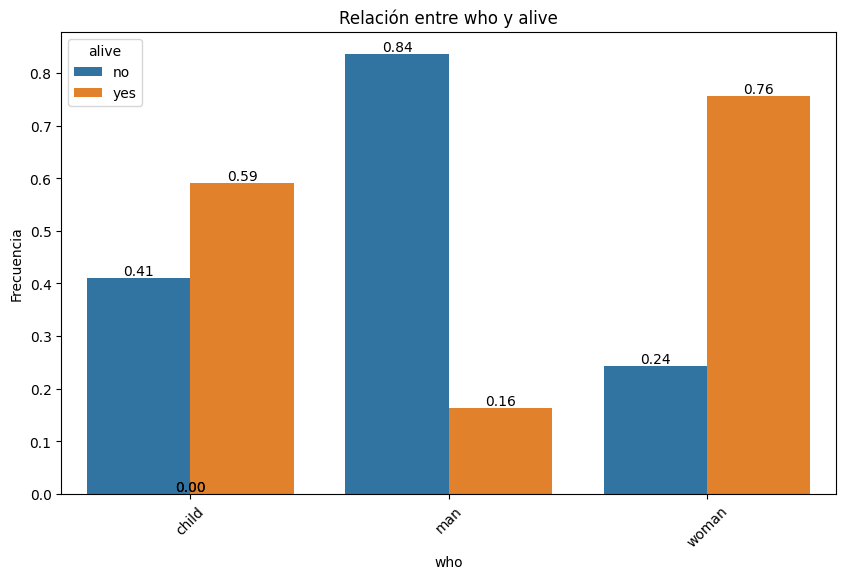

2. Comparar la clase del billete con si sobrevivieron o no


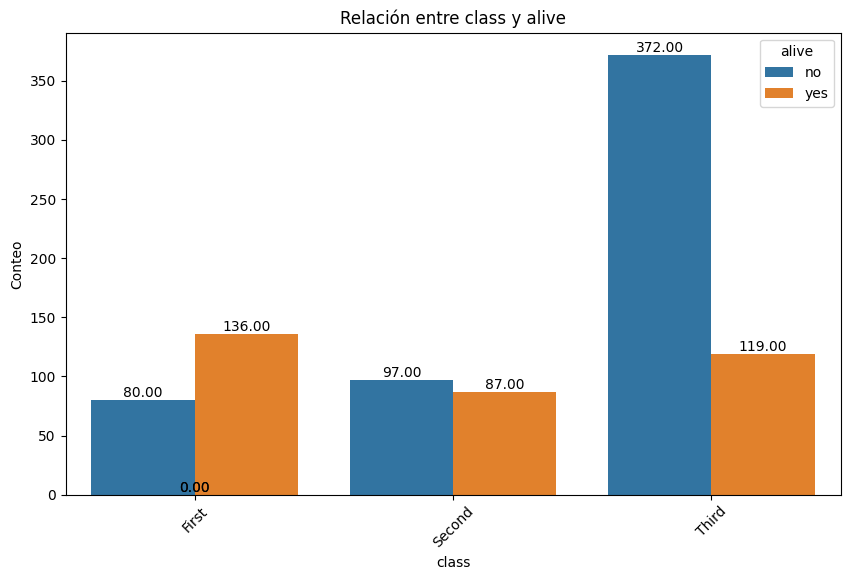

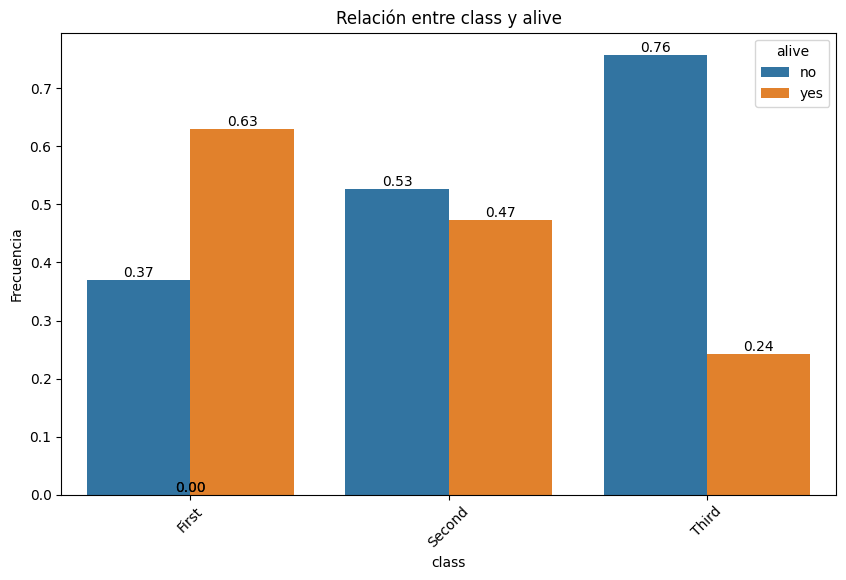

3. Análisis de supervivencia según el puerto de origen


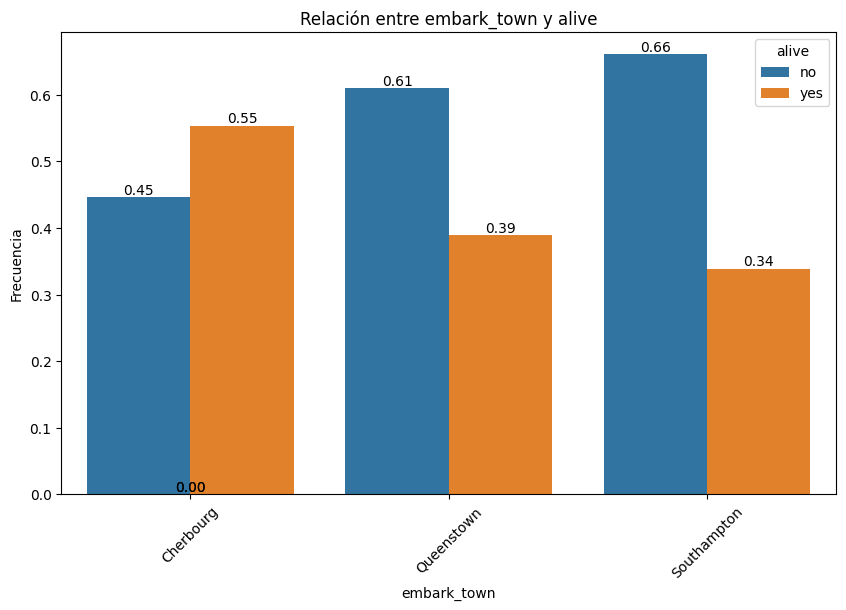

4. Comparación de una variable numérica (fare) con una categórica (alive)


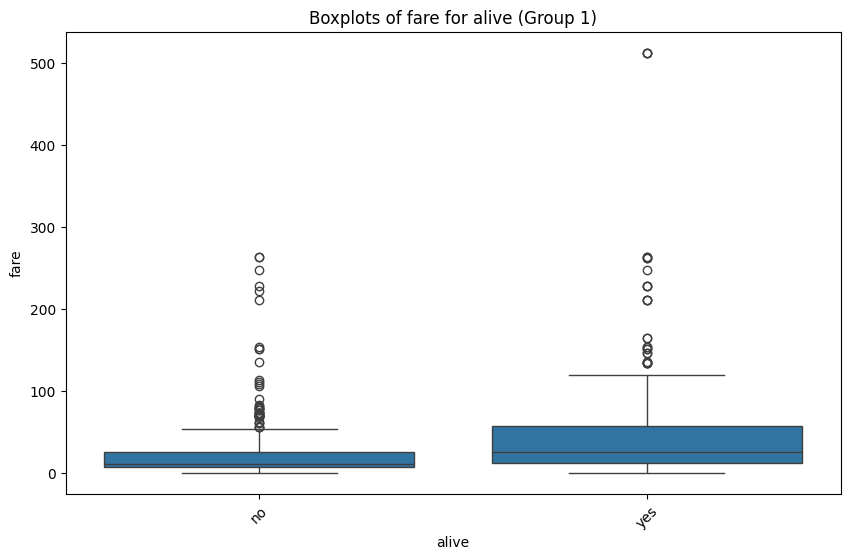

5. ¿Quién no paga?
Número de pasajeros con tarifa 0: 15


,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
179,male,36.000000,0.0,Third,man,True,Southampton,no,True,0
263,male,40.000000,0.0,First,man,True,Southampton,no,True,0
271,male,25.000000,0.0,Third,man,True,Southampton,yes,True,0
277,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
302,male,19.000000,0.0,Third,man,True,Southampton,no,True,0



Pasajero/s que más dinero dejó:


,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
258,female,35.0,512.3292,First,woman,False,Cherbourg,yes,True,0
679,male,36.0,512.3292,First,man,True,Cherbourg,yes,False,1
737,male,35.0,512.3292,First,man,True,Cherbourg,yes,True,0


6. Análisis de la relación entre edad y tarifa
Media de tarifa por ciudad y estado de supervivencia:


alive,no,yes
embark_town,,
Cherbourg,35.443335,79.720926
Queenstown,13.335904,13.182227
Southampton,20.743987,39.916514


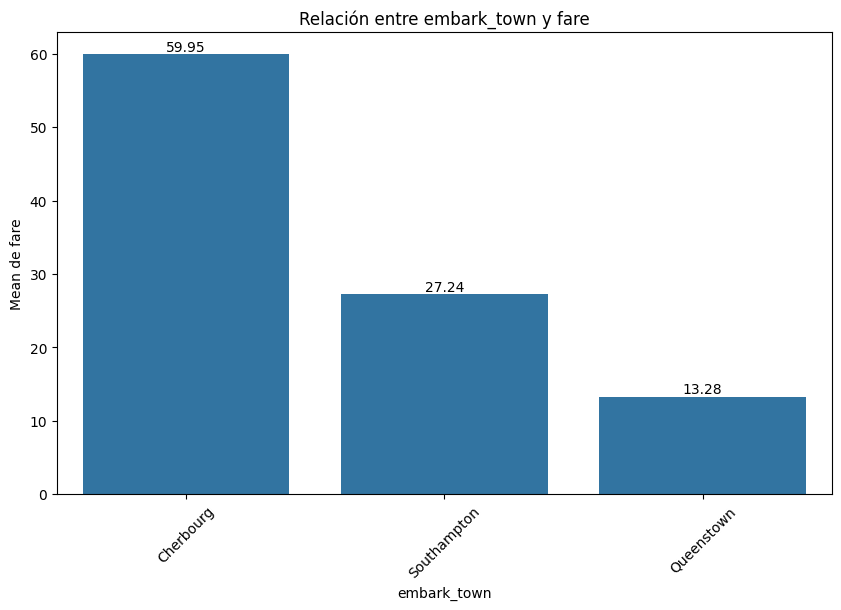

7.Relación entre Clase, Edad y Supervivencia
Análisis de Supervivencia por Clase (General):


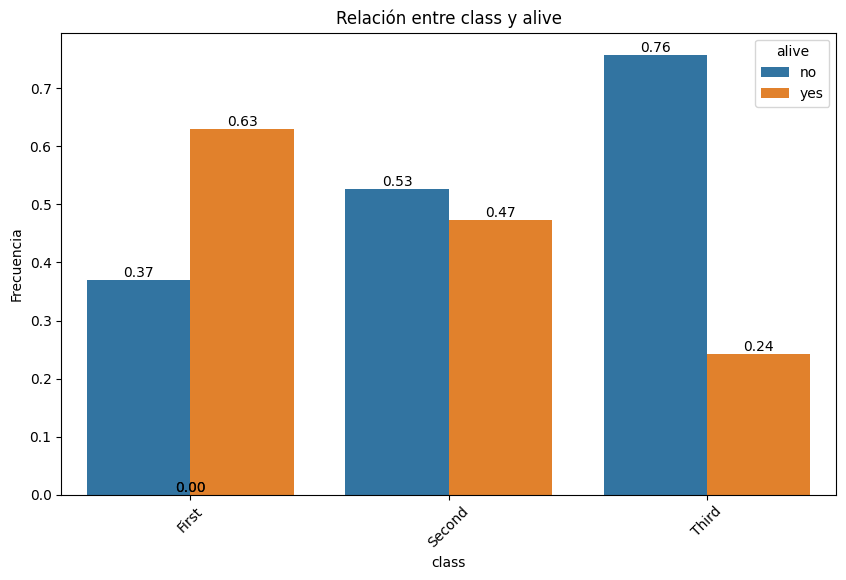


Tabla de supervivencia (Frecuencia relativa) por Clase y Grupo de Edad:


alive                     no       yes
class  age_group                      
First  Child        0.125000  0.875000
       Young Adult  0.333333  0.666667
       Adult        0.388889  0.611111
       Senior       0.785714  0.214286
Second Child        0.206897  0.793103
       Young Adult  0.571429  0.428571
       Adult        0.617021  0.382979
       Senior       0.666667  0.333333
Third  Child        0.648936  0.351064
       Young Adult  0.760479  0.239521
       Adult        0.913793  0.086207
       Senior       0.800000  0.200000

8.Relación Final: Edad, Coste del billete y Supervivencia


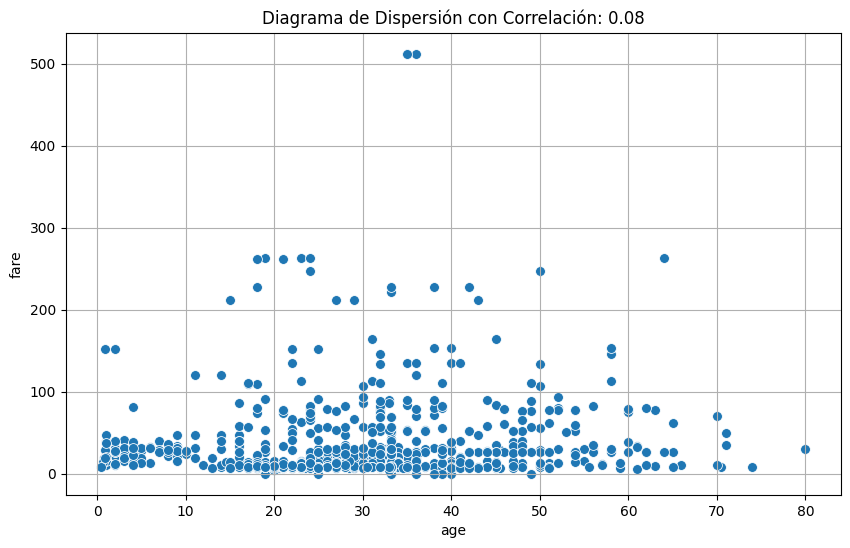

Burbujas: Edad vs Tarifa (Tamaño basado en miembros de la familia)


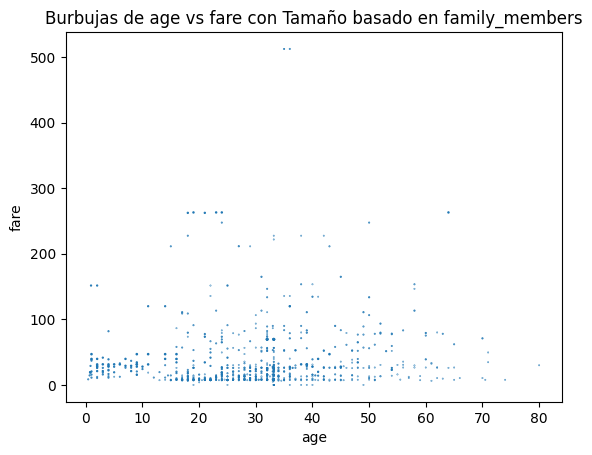

In [9]:
print("1. Análisis visual de supervivencia por grupo (man, woman, child)")
plot_categorical_relationship_fin(df_titanic, 'who', 'alive', relative_freq=False, show_values=True)
plot_categorical_relationship_fin(df_titanic, 'who', 'alive', relative_freq=True, show_values=True)

print("2. Comparar la clase del billete con si sobrevivieron o no")
plot_categorical_relationship_fin(df_titanic, 'class', 'alive', relative_freq=False, show_values=True)
plot_categorical_relationship_fin(df_titanic, 'class', 'alive', relative_freq=True, show_values=True)

print("3. Análisis de supervivencia según el puerto de origen")
plot_categorical_relationship_fin(df_titanic, 'embark_town', 'alive', relative_freq=True, show_values=True)

print("4. Comparación de una variable numérica (fare) con una categórica (alive)")
plot_grouped_boxplots(df_titanic, 'alive', 'fare')

print("5. ¿Quién no paga?")
gratis = df_titanic[df_titanic['fare'] == 0]
print(f"Número de pasajeros con tarifa 0: {len(gratis)}")
display(gratis.head())
# El pasajero que más pagó
max_fare = df_titanic[df_titanic['fare'] == df_titanic['fare'].max()]
print("\nPasajero/s que más dinero dejó:")
display(max_fare)

print("6. Análisis de la relación entre edad y tarifa")
# 1.Uso la función de relación Categórica-Numérica
print("Media de tarifa por ciudad y estado de supervivencia:")
display(df_titanic.groupby(['embark_town', 'alive'])['fare'].mean().unstack())
# 2.Visualizo la relación de Tarifa según la Ciudad de Embarque
plot_categorical_numerical_relationship(df_titanic, 'embark_town', 'fare', measure='mean', show_values=True)

print("7.Relación entre Clase, Edad y Supervivencia")
#1.Creamos rangos de edad para facilitar el análisis
df_titanic['age_group'] = pd.cut(df_titanic['age'], 
                                 bins=[0, 18, 35, 60, 100], 
                                 labels=['Child', 'Young Adult', 'Adult', 'Senior'])

#2.Analizamos la supervivencia combinando Clase y este nuevo grupo de Edad
print("Análisis de Supervivencia por Clase (General):")
plot_categorical_relationship_fin(df_titanic, 'class', 'alive', relative_freq=True, show_values=True)

#3.Para ver la interacción de las tres, calculamos una tabla de frecuencias
print("\nTabla de supervivencia (Frecuencia relativa) por Clase y Grupo de Edad:")
tabla_resumen = df_titanic.groupby(['class', 'age_group'], observed=True)['alive'].value_counts(normalize=True).unstack()
display(tabla_resumen)

print("8.Relación Final: Edad, Coste del billete y Supervivencia")
#1.Correlación entre Edad y Tarifa
grafico_dispersion_con_correlacion(df_titanic, 'age', 'fare', mostrar_correlacion=True)

# 2.Bubble Plot (Gráfico de burbujas)
# X = Edad, Y = Tarifa, Tamaño = Miembros de la familia (para usar la 3ª variable numérica que creo)
print("Burbujas: Edad vs Tarifa (Tamaño basado en miembros de la familia)")
bubble_plot(df_titanic, 'age', 'fare', 'family_members', scale=10)


## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

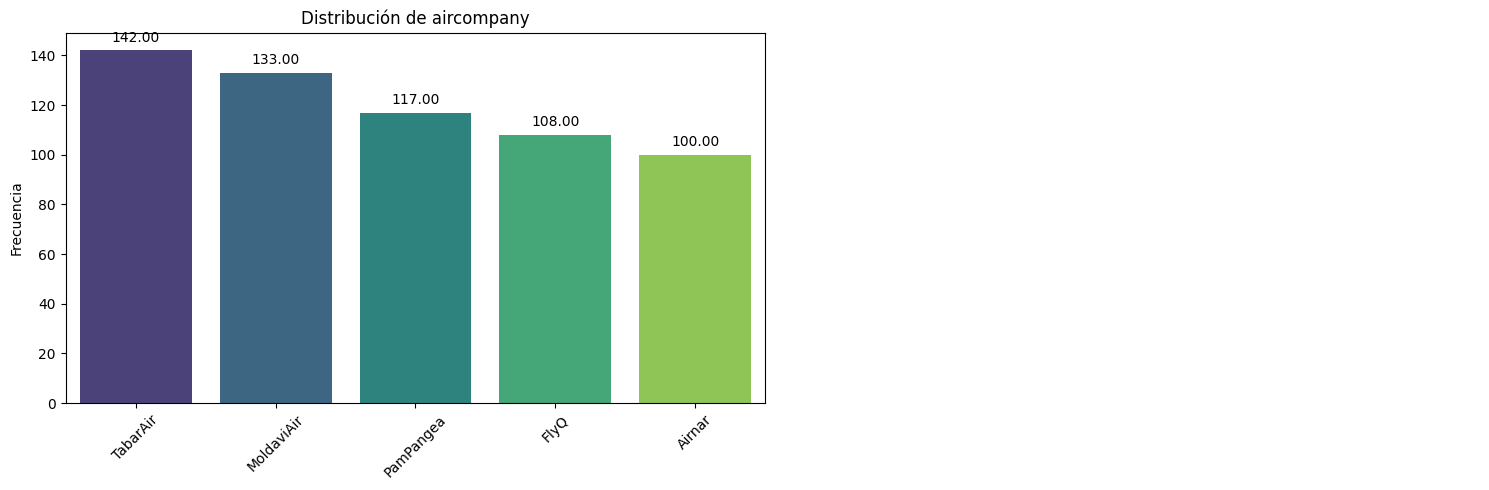

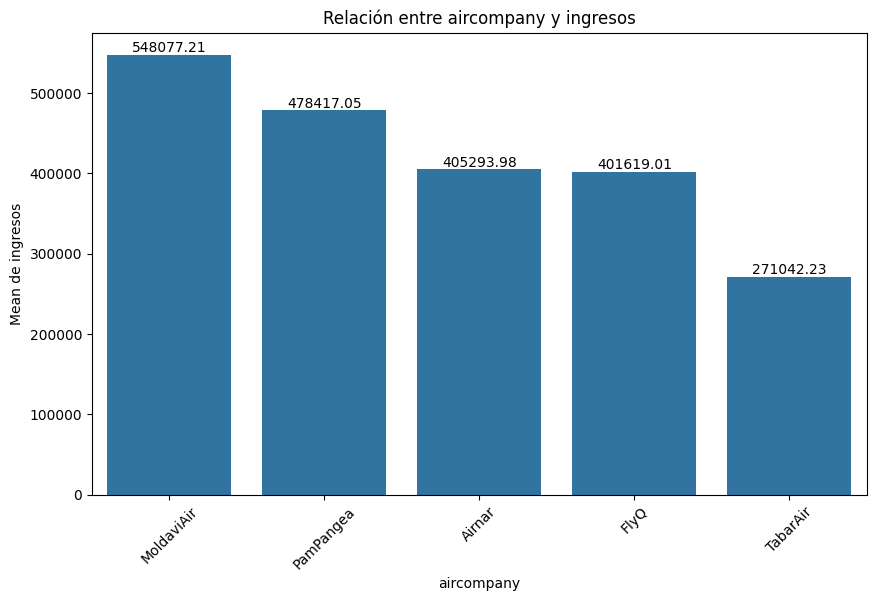

In [17]:
df_air_jun = pd.read_csv("data/dataset_viajes_jun.csv")

# 2. Análisis de frecuencias
pinta_distribucion_categoricas(df_air_jun, ["aircompany"], mostrar_valores=True)

# 3. Ingresos medios por compañía
plot_categorical_numerical_relationship(df_air_jun, "aircompany", "ingresos", measure="mean", show_values=True)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

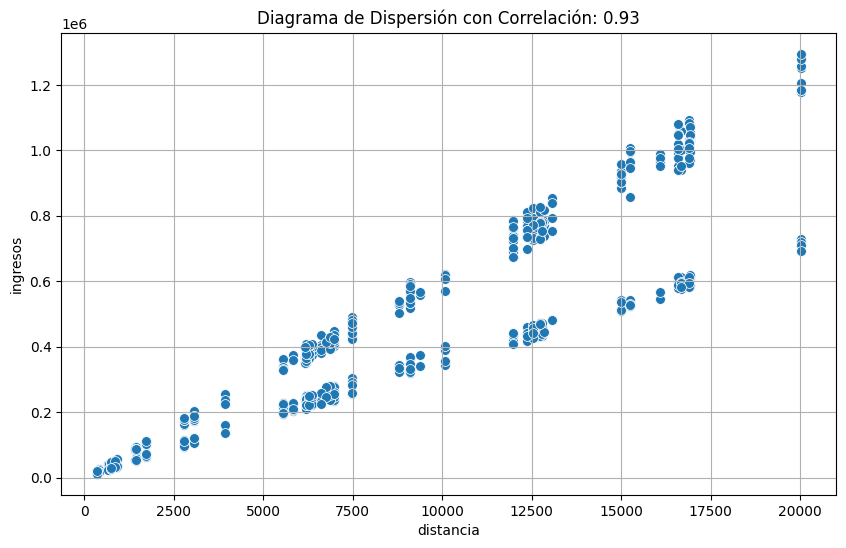

Relación Distancia-Ingresos (Tamaño = Consumo)


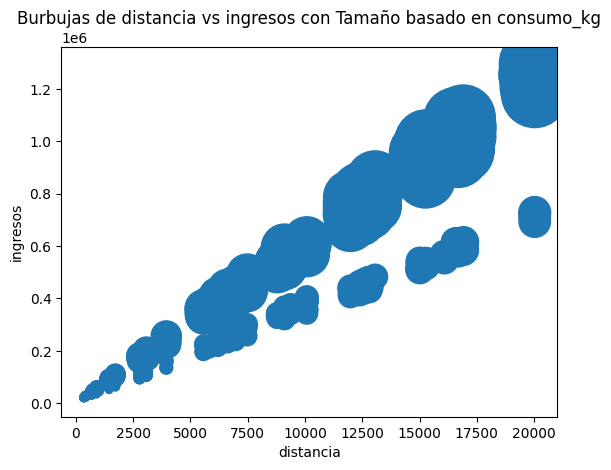

In [19]:
#Dispersión con correlación entre distancias e ingresos
grafico_dispersion_con_correlacion(df_air_jun, "distancia", "ingresos", mostrar_correlacion=True)

#Bubble Plot para ver el consumo
print("Relación Distancia-Ingresos (Tamaño = Consumo)")
bubble_plot(df_air_jun, "distancia", "ingresos", "consumo_kg", scale=100)

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

Ingresos medios según el alcance del vuelo:


c:\Users\lolar\Documents\GitHub\DS-Online-Lola\03_Data_Analysis\Sprint_07\Unidad_02_Estadistica_Descriptiva_Multivariante\03_Practica_Obligatoria\bootcampviztools.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby(categorical_col)[numerical_col].mean()


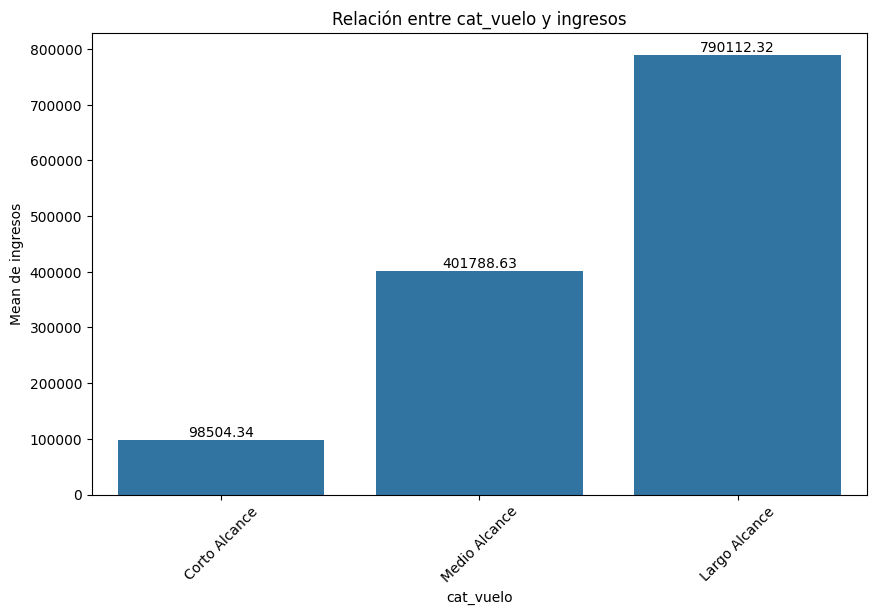

Consumo medio según el alcance del vuelo:


c:\Users\lolar\Documents\GitHub\DS-Online-Lola\03_Data_Analysis\Sprint_07\Unidad_02_Estadistica_Descriptiva_Multivariante\03_Practica_Obligatoria\bootcampviztools.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby(categorical_col)[numerical_col].mean()


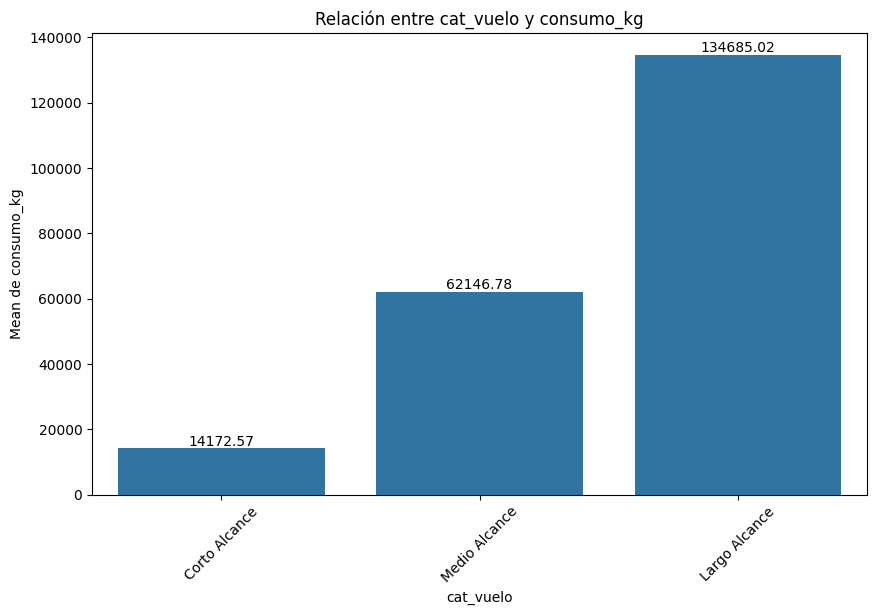

In [20]:
#Creo 'cat_vuelo' basada en la columna 'distancia'
df_air_jun['cat_vuelo'] = pd.qcut(df_air_jun['distancia'], q=3, 
                                  labels=['Corto Alcance', 'Medio Alcance', 'Largo Alcance'])

#Análisis de Ingresos por la nueva categoría
print("Ingresos medios según el alcance del vuelo:")
plot_categorical_numerical_relationship(df_air_jun, "cat_vuelo", "ingresos", measure="mean", show_values=True)

# Análisis de Consumo por la nueva categoría
print("Consumo medio según el alcance del vuelo:")
plot_categorical_numerical_relationship(df_air_jun, "cat_vuelo", "consumo_kg", measure="mean", show_values=True)